# Softmax Regression
> drug_class.csv

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions


from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [30]:
df = pd.read_csv('drug_class.csv')
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,M,LOW,HIGH,7.301033,drugC
1,69,M,LOW,HIGH,15.478000,drugY
2,74,M,HIGH,HIGH,9.516477,drugB
3,60,M,HIGH,NORMAL,8.742942,drugB
4,39,F,NORMAL,NORMAL,9.715872,drugX


In [31]:
# total classes
df['Class'].unique()

array(['drugC', 'drugY', 'drugB', 'drugX', 'drugA'], dtype=object)

In [32]:
# encoding classes

encoder = LabelEncoder()
df['Class'] = encoder.fit_transform(df['Class'])
df['Gender'] = encoder.fit_transform(df['Gender'])
df['BloodPressure'] = encoder.fit_transform(df['BloodPressure'])
df['Cholestrol'] = encoder.fit_transform(df['Cholestrol'])

In [33]:
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,1,1,0,7.301033,2
1,69,1,1,0,15.478000,4
2,74,1,0,0,9.516477,1
3,60,1,0,1,8.742942,1
4,39,0,2,1,9.715872,3


In [34]:
# features and target
x = df.iloc[:, 0:5]
y = df.iloc[:,-1]


# data split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [35]:
# model train
sr = LogisticRegression(multi_class='multinomial')      # prompts softmax regression
sr.fit(x_train, y_train)
y_Pred = sr.predict(x_test)

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
# intercept and coef
print('intercept: ',sr.intercept_)
print('coef: ',sr.coef_)

intercept:  [ 2.85274626 -1.39658672  2.2505926   0.44857877 -4.1553309 ]
coef:  [[-0.0372156   0.42408938 -3.86989075 -0.52194201  0.09492333]
 [ 0.14327464 -1.42135462 -4.23967639 -0.27788961 -0.23078387]
 [-0.02384702  0.57364232  1.72451755 -2.59867637 -0.04957417]
 [-0.02374391  0.10864551  4.74541004  3.35483327 -0.32987719]
 [-0.0584681   0.31497741  1.63963956  0.04367472  0.5153119 ]]


In [37]:
# accuracy
print('accuracy: ',accuracy_score(y_test, y_Pred) * 100)

accuracy:  93.4065934065934


Text(0.5, 1.0, 'Confusion matrix')

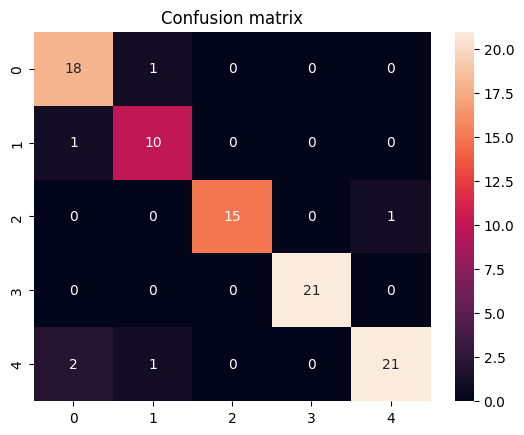

In [38]:
# confusion matrix
sns.heatmap(confusion_matrix(y_test, y_Pred), annot=True)
plt.title('Confusion matrix')

In [39]:
# user input query
user_ip = np.array([[23,1,1,0,7.301033]])

In [40]:
# probability of respective classes
sr.predict_proba(user_ip)

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[9.35183100e-03, 8.58019215e-05, 7.57388333e-01, 2.08435139e-01,
        2.47388945e-02]])

In [41]:
# class prediction
sr.predict(user_ip)

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([2])

> <span style= 'color:orange'>since we cant plot more than 3 dimensions, we must use PCA to visualize using all features.</span>


/Users/lucifer/Library/Python/3.9/lib/python/site-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


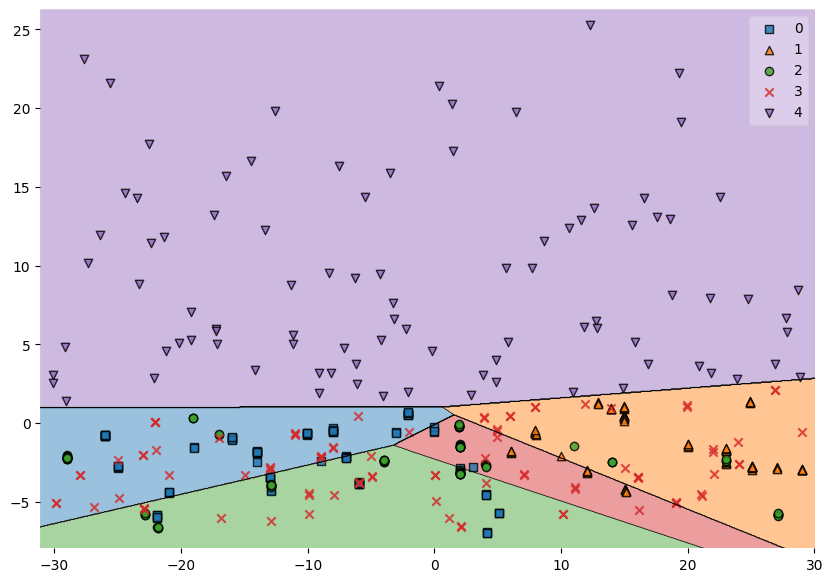

In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_pca, y, test_size=0.2, random_state=42
)

sr2 = LogisticRegression(max_iter=1000)
sr2.fit(x_train, y_train)

plt.figure(figsize=(10,7))
plot_decision_regions(x_pca, y.values, clf=sr2, legend=1)
plt.show()